# Cortical TRF analysis

This notebook checks how well cortical EEG responses can be predicted
from the speech envelope (gammatone predictors), and compares the
foreground story, the background story, and their mixture across the
different listening conditions (clean / diotic / binaural / dichotic).

Run this after data/bids_extraction.py and predictors/gammatone_predictors.py,
with analysis/experiment.py in the same folder (it is imported below).

## What happens, top to bottom

- Import eelbrain and load `e`, the pipeline object set up in
  `experiment.py` (this is where the actual EEG/predictor data gets
  pulled in).
- Mark bad channels and fit ICA for every subject (interactive, only
  needs doing once per subject - see the cell right after this).
- Load every subject's trigger/event information.
- Set up the display names, colors, and shared TRF-fitting settings
  reused by every section below.
- Define a region of interest (a set of electrodes over the front and
  middle of the head) and plot it, since later steps average over it
  instead of showing every electrode separately.
- Sanity check: confirm the basic sound-envelope predictor explains
  the EEG response at all, for every subject.
- Compare the foreground, background, and mixture predictors during
  the dichotic condition, split by which ear the background story
  came from, and test whether that difference is statistically real.
- Repeat that same foreground/background/mixture comparison across all
  three two-speaker conditions (diotic, binaural, dichotic), and test
  whether the differences between conditions are statistically real.
- Plot the TRFs themselves (the shape of the brain's response over
  time): first for a single speaker with no competing story, then for
  two speakers under each spatial condition.
- Find the timing of each response's peak and compare it by condition
  and by predictor.

Each section builds on the ones before it, so the cells are meant to
be run top to bottom, in order.

In [1]:
from pathlib import Path

from eelbrain import *
from experiment import e, topomap_with_colorbar, topomap_by_subject_with_colorbar

# Where to save plots.
DST = Path('~/Desktop').expanduser()


INFO    :  *** BinauralCocktail initialized with root /Users/joshuaighalo/Github Repositories/dataset/cocktail/bids on 2026-09-08 17:00:49 ***
INFO    :  Using eelbrain 0.0.0, mne 1.12.1.


## Preprocessing (run once per subject)

Marks bad channels (`mark_bad_channels()`) and fits ICA / picks
artifact components (`select_ica_artifacts()`) for every subject
(`sub-01` through `sub-13`) - two separate functions, run one after
the other in the two cells below, since bad channels have to be
marked before ICA is fit on top of them. Both steps can be done
interactively (a plot opens and pauses the notebook until you close
it, then the next subject's plot opens automatically) or
automatically instead - see the `MANUAL_BAD_CHANNELS` and
`MANUAL_ICA` toggles in the cells below.

Automatic ICA rejection also writes a numbered grid image and a .tsv
of every component's label/confidence/reject-status per subject, under
`derivatives/mne/sub-XX/eeg/sub-XX_task-cocktail_desc-iclabel_components.*` -
worth a look even if you mostly trust the automatic call, since the
image lets you spot-check it against the numbers.

Before running anyone, each function checks which requested subjects
already have a file saved. If any do, it asks (a plain text prompt
below the cell, not a GUI window) whether to skip or redo them -
pressing enter or typing anything but `r` skips. With `'all'` (the
default here), that's one combined question covering every
already-done subject at once, not a prompt per subject - so if
everyone's already done, re-running these cells just needs one quick
confirm, not 13 interactive steps. Pass `confirm_overwrite=False` to
turn the prompts off and always redo every requested subject. Both
functions also accept a single subject instead of `'all'` (e.g.
`e.mark_bad_channels(1)`), the same convention `load_trfs()` uses
below, if you just want to redo (and get asked about) one subject.

`select_ica_artifacts()` also checks each already-done subject's ICA
against their *current* bad channels, and forces a redo automatically
- no prompt - for anyone where the two no longer match (typically
because `mark_bad_channels()` changed what's excluded for them since
ICA was last fit). Left alone, that mismatch doesn't fail here - it
fails later, as a `ProtectedArtifactError`, the first time something
else (e.g. `load_trfs()`) needs that subject's data.


In [2]:
# Bad channels: pick by hand in a GUI (MANUAL_BAD_CHANNELS = True), or
# find them automatically instead (MANUAL_BAD_CHANNELS = False) using
# eelbrain's own neighbor-correlation check - any channel correlating
# with its neighbors below AUTO_BAD_CHANNELS_R gets marked bad, with no
# window to close. This check is relative to whichever channels are
# already excluded, so re-running it adds to (not replaces) a previous
# run's result by default - set REDO_BAD_CHANNELS = True to clear a
# subject's previous automatic result first and start fresh instead of
# compounding on top of it.
MANUAL_BAD_CHANNELS = False
AUTO_BAD_CHANNELS_R = 0.3  # only used when MANUAL_BAD_CHANNELS is False
REDO_BAD_CHANNELS = True  # only used when MANUAL_BAD_CHANNELS is False

e.mark_bad_channels(
    'all',
    manual_bad_channels=MANUAL_BAD_CHANNELS, auto_bad_channels_r=AUTO_BAD_CHANNELS_R,
    redo_bad_channels=REDO_BAD_CHANNELS,
)


  skipping (already done): 01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12, 13

Done. Bad channels marked.


In [3]:
# ICA components: pick by hand in a GUI (MANUAL_ICA = True), or find
# artifact components automatically instead (MANUAL_ICA = False) using
# mne-icalabel's ICLabel classifier - any component predicted as eye
# blink / muscle / heart beat / line noise / channel noise with at
# least AUTO_ICA_CONFIDENCE gets excluded, with no window to close.
MANUAL_ICA = False
AUTO_ICA_CONFIDENCE = 0.75  # only used when MANUAL_ICA is False

e.select_ica_artifacts(
    'all',
    manual_ica=MANUAL_ICA, auto_ica_confidence=AUTO_ICA_CONFIDENCE,
)


  skipping (already done): 01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12, 13

Done. ICA fit and artifact components selected.


In [4]:
e.load_events()

#,onset,duration,trial_type,value,sample,subject,list_id,condition,fg,bg,mix,side
0,21.011,257.15,code_2,2,86063,13,2,clean,female_1,,,
1,315.12,251.81,code_2,2,1290733,13,2,binaural,female_2,male_2,List_2_stim_2,left
2,618.22,240.03,code_2,2,2532226,13,2,dichotic,female_3,male_3,List_2_stim_3,right
3,898.35,247.96,code_2,2,3679657,13,2,diotic,female_4,male_4,List_2_stim_4,
4,1192,250.5,code_2,2,4882393,13,2,binaural,female_5,male_5,List_2_stim_5,right
5,1480.4,245.64,code_2,2,6063519,13,2,dichotic,female_6,male_6,List_2_stim_6,left
6,1769,242.72,code_2,2,7245966,13,2,clean,male_7,,,
7,2039.8,242.89,code_2,2,8355215,13,2,binaural,male_8,female_8,List_2_stim_8,right
8,2326.6,248.46,code_2,2,9529785,13,2,dichotic,male_9,female_9,List_2_stim_9,left
9,2623.9,241.77,code_2,2,10747527,13,2,diotic,male_10,female_10,List_2_stim_10,


In [5]:
EPOCHS = ['diotic', 'binaural', 'dichotic']

# Human-readable names and colors for the three predictors we compare
# throughout this notebook: the foreground story, the background story,
# and the mixture of both.
LABELS = {
    'gammatone_on_1': 'Foreground',
    'bg_gammatone_on_1': 'Background',
    'mix_gammatone_on_1': 'Mixture',
}
COLORS = {
    'gammatone_on_1': 'red',
    'bg_gammatone_on_1': 'blue',
    'mix_gammatone_on_1': '.3',
}

In [6]:
# Settings shared by every TRF estimated in this notebook: which
# preprocessed EEG to use, how many subjects, the response time window
# to fit (-100 to 600 ms relative to sound onset). The boosting
# algorithm's own settings (error, basis, partitions,
# selective_stopping) live in experiment.py's `estimators` now, not
# here. See https://eelbrain.readthedocs.io/en/stable/experiment.html
# for what each of these controls.
PARAMETERS = {
    'raw': 'ica',
    'group': 'all',
    'samplingrate': 128,
    'data': 'eeg',
    'tstart': -0.100,
    'tstop': 0.600,
}

A small helper used throughout this notebook: eelbrain's own
`Pipeline` class has `load_model_test()` built in (runs a model
comparison and returns a statistical test result), but not a
plotting convenience on top of it (the old `trftools` package had
one, `show_model_test()`, which isn't available here - see the
Setup section of the README). This wraps `load_model_test()` for a
whole dictionary of named comparisons at once and plots a topomap of
each, passing the result straight to `plot.Topomap()` (the standard
way to show a masked-by-significance effect map in eelbrain). This
one is a reconstruction rather than a direct copy of the original
convenience function - if the plot doesn't look like what "masked by
significance" should look like, check `plot.Topomap`'s docs for the
exact way it expects a test result.

In [7]:
def show_model_test(comparisons, vmax=None, **kwargs):
    for label, comparison in comparisons.items():
        result = e.load_model_test(comparison, **kwargs)
        display(plot.Topomap(result, vmax=vmax, title=label))

## Define a region of interest (ROI)

Cortical speech responses are usually strongest over fronto-central
electrodes, so later plots average over this set of sensors instead of
showing every electrode separately.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


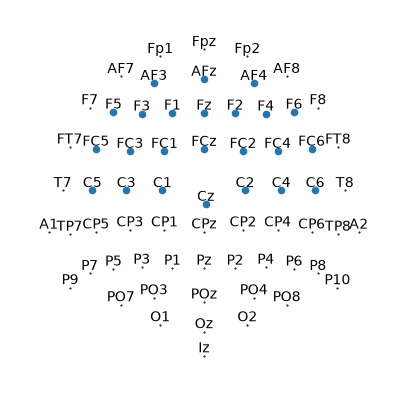

In [8]:
data = e.load_trfs(1, 'gammatone-1', epoch='clean', **PARAMETERS)
eeg = data['ev']

ROI = [
    'AF3', 'F1', 'F3', 'F5',
    'FC5', 'FC3', 'FC1',
    'C1', 'C3', 'C5',
    'AF4', 'AFz',
    'Fz', 'F2', 'F4', 'F6',
    'FC6', 'FC4', 'FC2', 'FCz',
    'Cz', 'C2', 'C4', 'C6',
]

p = plot.SensorMap(eeg, mark=ROI)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


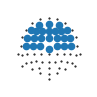

In [9]:
# A cleaner version of the same plot, for use in a figure.
p = plot.SensorMap(eeg, w=1, h=1, labels=False, mark=ROI)
p.save(DST / 'ROI.pdf')

## Envelope model

First, a sanity check: does the simple envelope predictor
("gammatone-1", the foreground story's overall loudness over time)
predict the EEG at all, for every subject?

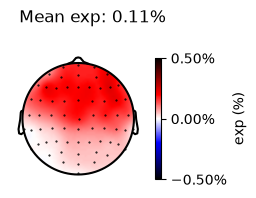

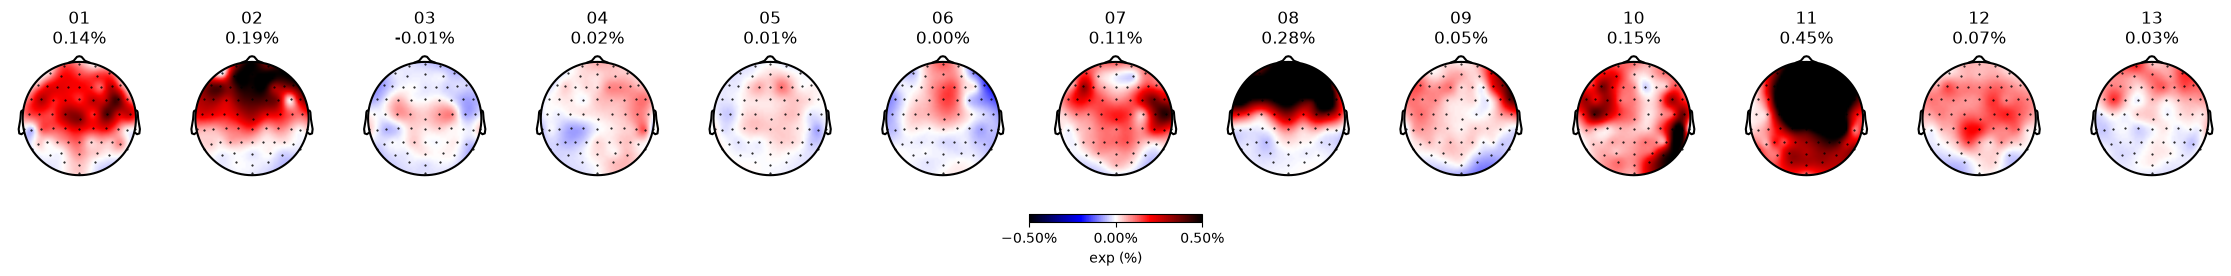

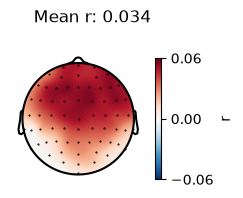

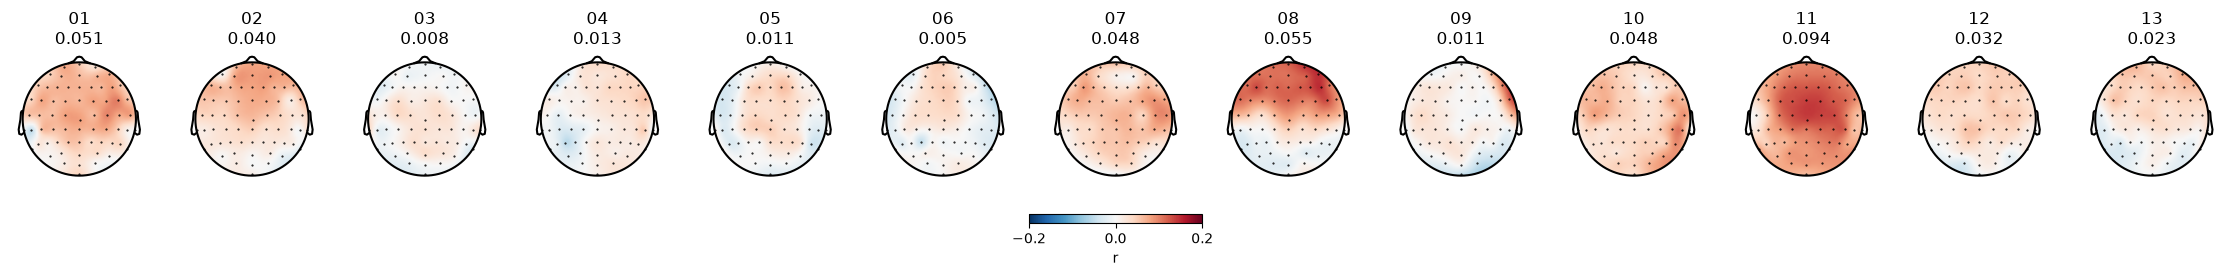

In [10]:
PREDICTOR = 'gammatone-1'
data = e.load_trfs('all', PREDICTOR, epoch='clean', **PARAMETERS)

# Proportion of variance explained ('ev', displayed as "exp") - values
# are tiny (a fraction of a percent), so a fixed, narrow vmax keeps the
# color scale usable. It's a fraction, so shown as a percentage.
TOPO_ARGS = dict(vmax=0.005, clip='circle')
p = topomap_with_colorbar('ev', data, label='exp', pct=True, predictor=PREDICTOR, **TOPO_ARGS)
p = topomap_by_subject_with_colorbar('ev', data, label='exp', pct=True, predictor=PREDICTOR, **TOPO_ARGS)

# Same, for the correlation between predicted and actual EEG ('r').
# r has a much larger natural range than ev, so it gets its own color
# scale instead of reusing TOPO_ARGS's vmax - letting Topomap pick one
# automatically from the data. r is already unitless (not a fraction
# of anything), so it's shown as a plain number, not a percentage.
TOPO_ARGS_R = dict(clip='circle')
p = topomap_with_colorbar('r', data, pct=False, predictor=PREDICTOR, **TOPO_ARGS_R)
p = topomap_by_subject_with_colorbar('r', data, pct=False, predictor=PREDICTOR, **TOPO_ARGS_R)


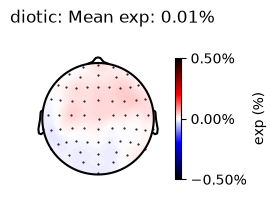

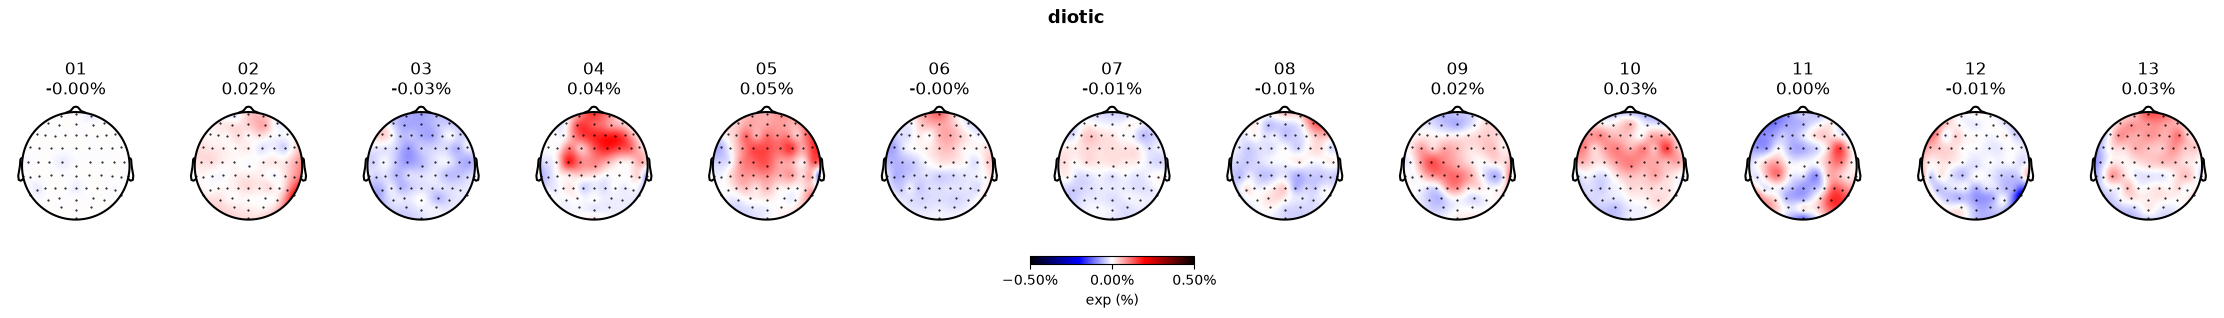

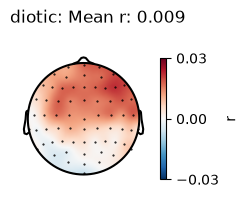

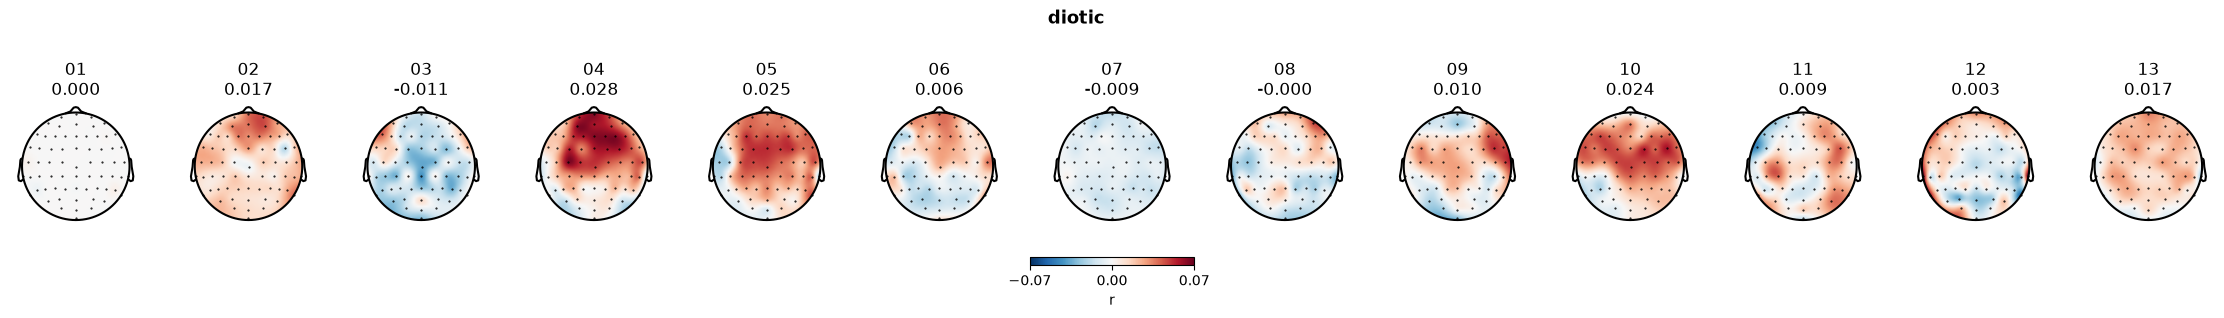

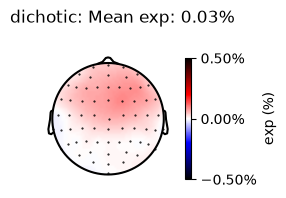

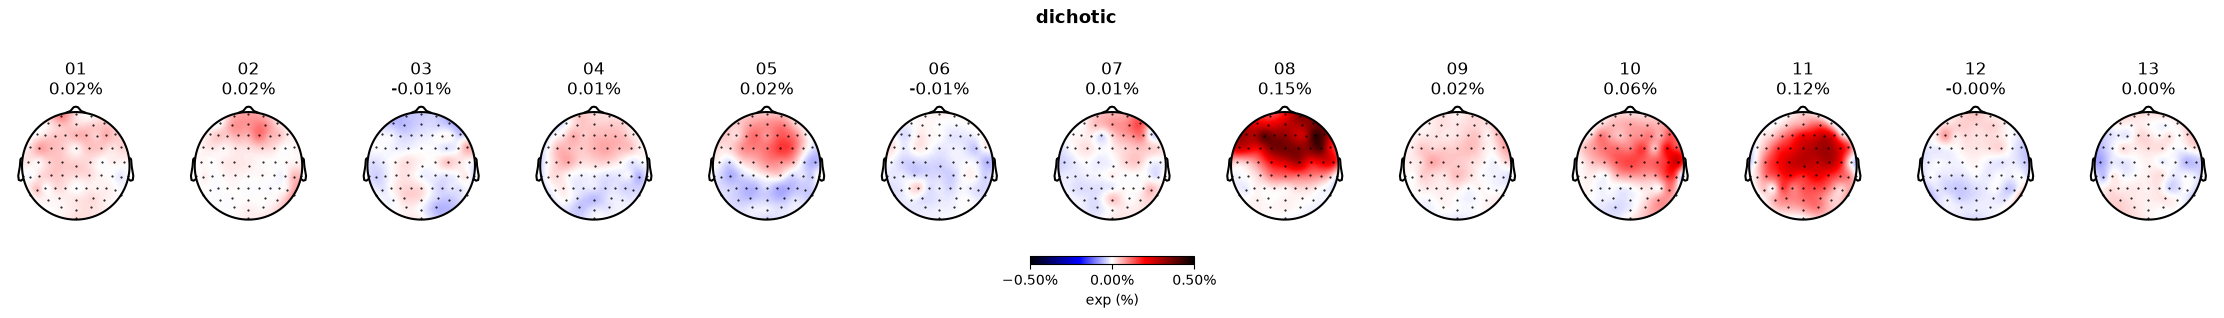

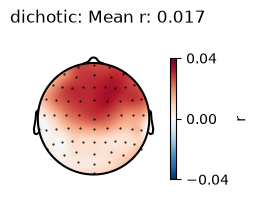

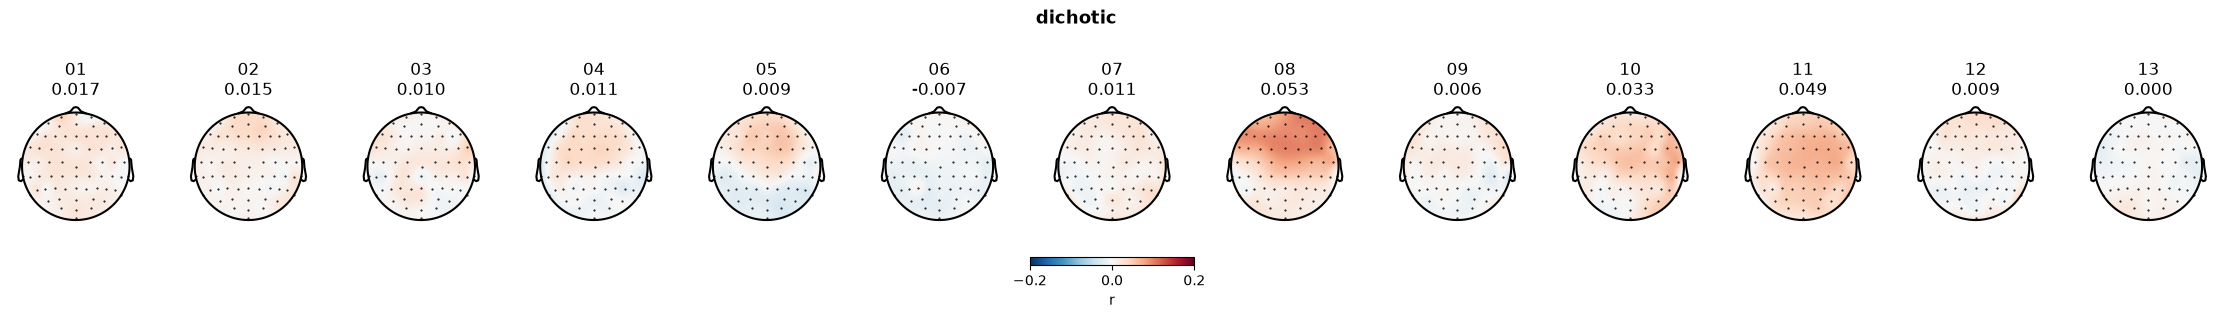

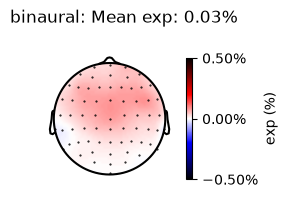

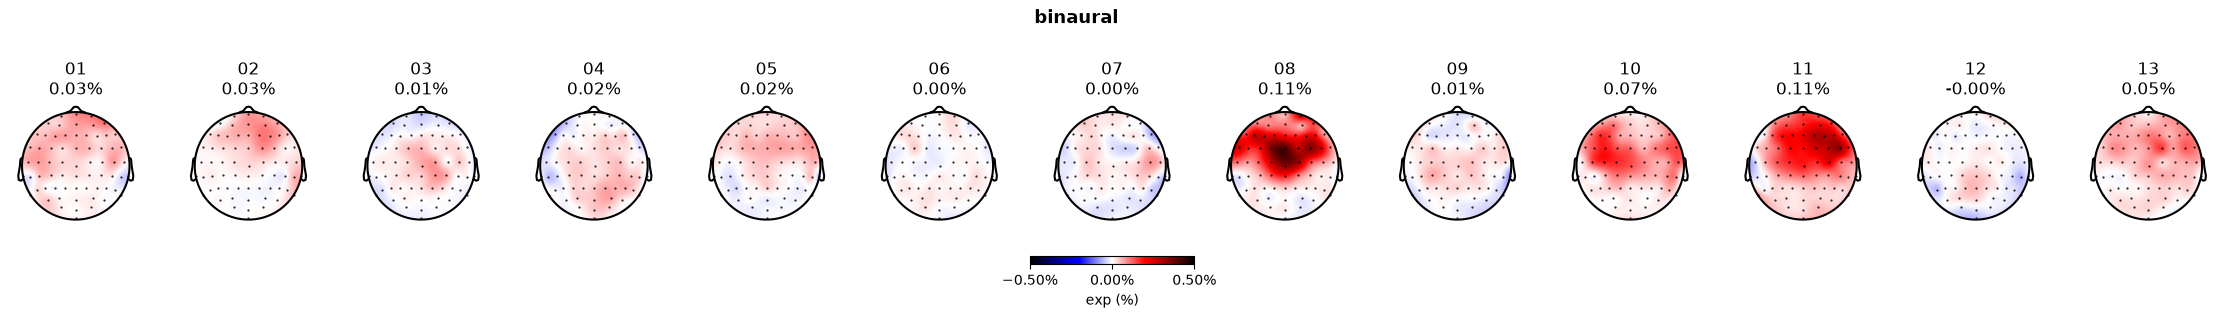

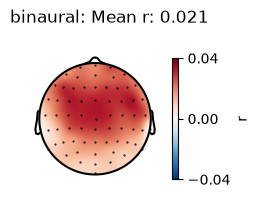

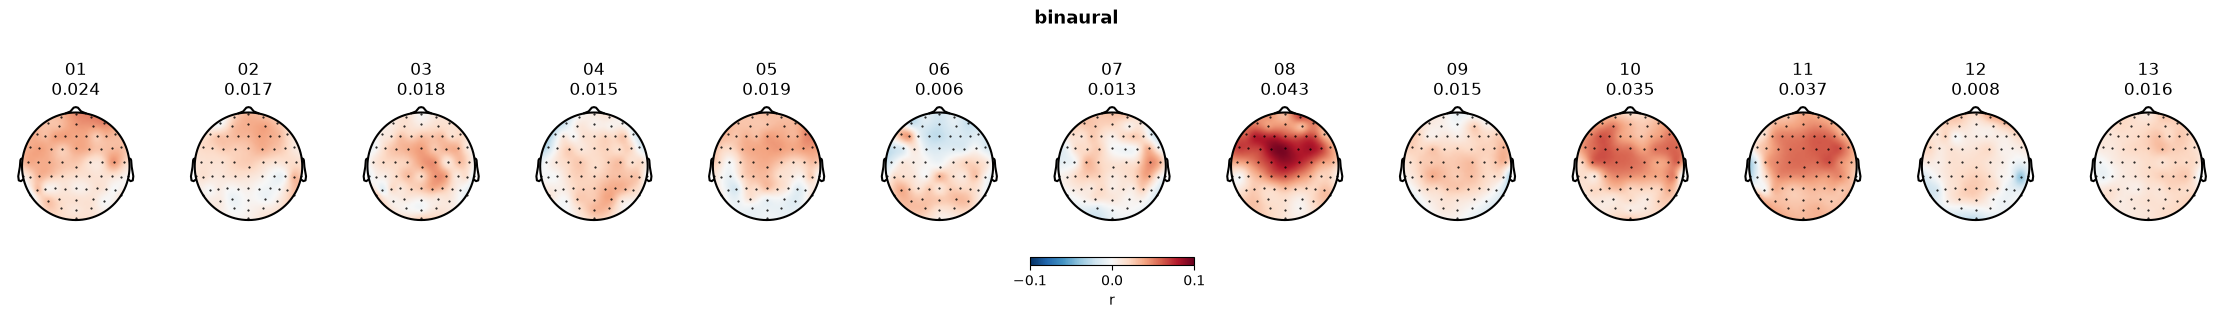

In [11]:
# Same check, now also including the background story as a predictor,
# separately for each listening condition. condition=epoch puts the
# condition name in each image's title, so the three conditions'
# plots stay distinguishable from each other.
PREDICTOR_BG = 'gammatone-1 + bg~gammatone-1'
for epoch in ['diotic', 'dichotic', 'binaural']:
    data = e.load_trfs('all', PREDICTOR_BG, epoch=epoch, **PARAMETERS)
    p = topomap_with_colorbar('ev', data, label='exp', pct=True, condition=epoch, predictor=PREDICTOR_BG, **TOPO_ARGS)
    p = topomap_by_subject_with_colorbar('ev', data, label='exp', pct=True, condition=epoch, predictor=PREDICTOR_BG, **TOPO_ARGS)

    # Same, for the correlation between predicted and actual EEG ('r') -
    # see the cell above for why it uses its own color scale and is
    # shown as a plain number rather than a percentage.
    p = topomap_with_colorbar('r', data, pct=False, condition=epoch, predictor=PREDICTOR_BG, **TOPO_ARGS_R)
    p = topomap_by_subject_with_colorbar('r', data, pct=False, condition=epoch, predictor=PREDICTOR_BG, **TOPO_ARGS_R)


## Dichotic: effect of ear

The auditory pathway crosses sides on its way to the brain, so a sound
in one ear is represented more strongly on the opposite side of the
brain. Since in the dichotic condition the background story always
comes from one ear, we might expect the cortical representation of
that background to depend on which ear it came from.

In [12]:
# Compare three predictors (foreground, background, mixture) against a
# combined model that includes all three, to see how much unique
# predictive power each one adds.
FULL = "gammatone-on-1 + bg~gammatone-on-1 + mix~gammatone-on-1"
COMPARISONS = {
    'fg': f"{FULL} @ gammatone-on-1",
    'bg': f"{FULL} @ bg~gammatone-on-1",
    'mix': f"{FULL} @ mix~gammatone-on-1",
}

In [13]:
show_model_test(COMPARISONS, **PARAMETERS, pmin=0.05, metric='ev', epoch='dichotic-left', vmax=.0005)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/joshuaighalo/Github Repositories/dataset/cocktail/bids/derivatives/predictors/List_1_stim_3~gammatone-on-1.pickle'

In [ ]:
show_model_test(COMPARISONS, **PARAMETERS, pmin=0.05, metric='ev', epoch='dichotic-right', vmax=.0005)

Collect the model comparisons for both ears so we can test whether the
difference is statistically meaningful.

In [ ]:
dss = []
for stream, comparison in COMPARISONS.items():
    for epoch in ['dichotic-left', 'dichotic-right']:
        data, result = e.load_model_test(comparison, **PARAMETERS, pmin=0.05, metric='ev', epoch=epoch, return_data=True)
        data = table.difference('ev', 'model', 'test', 'baseline', 'subject', data=data)
        data['stream', :] = stream
        dss.append(data)
data = combine(dss)
data['roi_ev'] = data['ev'].mean(sensor=ROI)

In [ ]:
test.ANOVA('roi_ev', 'stream * epoch * subject', sub="epoch != 'dichotic'", data=data)

In [ ]:
p = plot.Barplot('roi_ev', 'epoch', sub="stream == 'fg'", match='subject', data=data, h=2, w=2, corr=False, title='FG')
p.set_xtick_rotation(45)

## Effect of binaural cues

Now compare all three listening conditions that include a background
story (diotic, binaural, dichotic) to see whether the strength of the
background's cortical representation depends on the spatial cues
available to separate the two speakers.

In [ ]:
FULL = "gammatone-on-1 + bg~gammatone-on-1 + mix~gammatone-on-1"
COMPARISONS = {
    'fg': f"{FULL} @ gammatone-on-1",
    'bg': f"{FULL} @ bg~gammatone-on-1",
    'mix': f"{FULL} @ mix~gammatone-on-1",
}

Inadvertent attention switches (accidentally attending the wrong
story) are a possible confound, so check each condition individually
before comparing them.

In [ ]:
show_model_test(COMPARISONS, **PARAMETERS, pmin=0.05, metric='ev', epoch='diotic', vmax=.0005)

In [ ]:
show_model_test(COMPARISONS, **PARAMETERS, pmin=0.05, metric='ev', epoch='binaural', vmax=.0005)

In [ ]:
show_model_test(COMPARISONS, **PARAMETERS, pmin=0.05, metric='ev', epoch='dichotic', vmax=.0005)

### Is the difference between conditions reliable?

In [ ]:
dss = []
for stream, comparison in COMPARISONS.items():
    for epoch in ['diotic', 'dichotic', 'binaural']:
        data, result = e.load_model_test(comparison, **PARAMETERS, pmin=0.05, metric='ev', epoch=epoch, return_data=True)
        data = table.difference('ev', 'model', 'test', 'baseline', 'subject', data=data)
        data['stream', :] = stream
        dss.append(data)
data = combine(dss)
data['roi_ev'] = data['ev'].mean(sensor=ROI)
test.ANOVA('roi_ev', 'stream * epoch * subject', data=data)

In [ ]:
for stream in COMPARISONS:
    display(test.ANOVA('roi_ev', 'epoch * subject', sub=f"stream == '{stream}'", data=data, title=stream))
    p = plot.Barplot('roi_ev', 'epoch', sub=f"stream == '{stream}'", match='subject', data=data, h=2, w=2, corr=False, title=stream)
    p.set_xtick_rotation(45)

In [ ]:
# The p-value for the one comparison that came out significant above.
test.pairwise('roi_ev', 'epoch', sub="stream == 'bg'", match='subject', data=data, corr=False, title=False)

In [ ]:
# All pairwise comparisons, for reference.
test.pairwise('roi_ev', 'stream % epoch', match='subject', data=data, title=False)

## TRFs (temporal response functions)

A TRF shows the shape of the brain's response over time to a unit of
the predictor - essentially "if this sound feature occurred at time
0, how does the EEG respond over the following half second".

### Single speaker (no competing story)

In [ ]:
data = e.load_trfs(-1, 'gammatone-on-1', epoch='clean', **PARAMETERS)
trf = data['gammatone_on_1'].mean(sensor=ROI)
PLOT_ARGS = dict(frame='t', h=2.5, w=4, xlim=(-0.050, 0.550), clip=True, top=3.5, bottom=-0.5)
p = plot.UTSStat(trf * 1e3, **PLOT_ARGS)
p.save(DST / 'clean.pdf')

### Two speakers (foreground, background, and mixture)

In [ ]:
PLOT_ARGS['top'] = 2.5
all_dss = []
legend = True
for epoch in EPOCHS:
    data = e.load_trfs(-1, FULL, epoch=epoch, **PARAMETERS)

    dss = []
    for x in data.info['xs']:
        if '_on' not in x:
            # Only keep the onset-response predictors, matching FULL above.
            continue
        ds = data['subject',]
        ds[:, 'x'] = x
        ds[:, 'epoch'] = epoch
        ds['trf'] = data[x].mean(sensor=ROI)
        dss.append(ds)
        all_dss.append(ds)
    roi_data = combine(dss)
    p = plot.UTSStat('trf*1e3', 'x', data=roi_data, title=epoch.capitalize(), **PLOT_ARGS, labels=LABELS, colors=COLORS, legend=legend)
    p.save(DST / f'{epoch}.pdf')
    legend = False

roi_data = combine(all_dss)
# Smooth the TRFs to 512 samples for cleaner peak-time estimates below.
roi_data['trf_sm'] = resample(roi_data['trf'], 512)

In [ ]:
for epoch in EPOCHS:
    p = plot.UTSStat('trf_sm*1e3', 'x', sub=f"epoch == '{epoch}'", data=roi_data, title=epoch.capitalize(), **PLOT_ARGS, labels=LABELS, colors=COLORS, legend=legend)

## Peak response time

Find, for each subject/condition/predictor, the time of the largest
response between 20 and 130 ms - a typical window for the early
cortical response to speech onsets.

In [ ]:
roi_data['peak'] = roi_data['trf_sm'].sub(time=(0.02, 0.130)).argmax('time')

### Peak time by condition

In [ ]:
for epoch in EPOCHS:
    p = plot.Barplot('peak', 'x', match='subject', sub=f"epoch == '{epoch}'", data=roi_data, h=2, w=2.5, labels=LABELS, title=epoch, corr=False)
    display(test.pairwise('peak', 'x', match='subject', sub=f"epoch == '{epoch}'", data=roi_data, corr=False, title=False))
    p.set_xtick_rotation(30)

### Peak time by predictor (foreground / background / mixture)

In [ ]:
for x in COLORS:
    p = plot.Barplot('peak', 'epoch', match='subject', sub=f"x == '{x}'", data=roi_data, h=2, w=2.5, title=LABELS[x], corr=False)
    display(test.pairwise('peak', 'epoch', match='subject', sub=f"x == '{x}'", data=roi_data, corr=False, title=False))
    p.set_xtick_rotation(30)